In [ ]:
class LineOrdinalEncoder:
    """
    Кодирует разделенный запятыми список строк в список целых чисел, где каждое число соответствует уникальной строке
    """

    def __init__(self):
        self.__word_ids = dict()
        self.last_word_id = -1

    def __call__(self, line: str):
        words = line.split(',')
        encoded_line = []
        for w in words:
            if w not in self.__word_ids.keys():
                self.last_word_id += 1
                self.__word_ids[w] = self.last_word_id
            encoded_line.append(self.__word_ids[w])
        return encoded_line

    def decode(self, ord_items: list[int]):
        R = []
        for item in ord_items: R.append([i[0] for i in self.__word_ids.items() if i[1] == item][0])
        return R

def _ordinal_to_onehot(ordinal_lines: list[list[int]]) -> list[int]:
    """
    Переводит списки номеров товаров в битовые карты, кодирующие наборы
    :param ordinal_lines: ordinal-encoded наборы товаров (списки номеров товаров)
    :returns: Список битовых карт
    """
    one_hot_lines = []
    for line in ordinal_lines:
        one_hot_line = 0
        for item_id in line: one_hot_line += 1 << item_id
        one_hot_lines.append(one_hot_line)
    return one_hot_lines

def read_baskets(stream, ord_encoder) -> tuple[list[int], int]:
    """
    Читает наборы товаров из файла и кодирует их в битовые карты
    :returns: список закодированных в битовые строки транзакций и количество уникальных элементов в транзакциях
    """
    encoded_lines = []
    for line in stream.readlines():
        line = line.replace('\n', '')
        encoded_lines.append(ord_encoder(line))
    return _ordinal_to_onehot(encoded_lines), ord_encoder.last_word_id + 1

In [24]:
class ItemSet:

    def __init__(self, bitstring: int):
        # i-й бит кодирует наличие/отсутствие i-го товара в наборе
        self.bitstring = bitstring
        self.count = 0

    def __repr__(self) -> str:
        return "ItemSet([" + ", ".join([str(i) for i in self.items]) + f"], support = {self.count})"

    @property
    def items(self):
        item_numbers = []
        bitstring_cpy = self.bitstring
        i = 0
        while bitstring_cpy > 0:
            if bitstring_cpy % 2: item_numbers.append(i)
            bitstring_cpy >>= 1
            i += 1
        return item_numbers

    def __eq__(self, other): return self.bitstring == other.bitstring

    def __hash__(self): return self.bitstring

In [ ]:
from itertools import combinations
from math import log2, floor

def differ_in_exactly_one_item(p: ItemSet, q: ItemSet):
    """
    Проверяет, различаются ли наборы одинаковой длины только одним элементом (как, например, ABC и ABD)
    :param p: проверяемый набор
    :param q: проверяемый набор
    :returns: True, если условие выполняется, иначе False
    """
    # Искать транзакции, различающиеся всего одним элементом, можно так: применить побитовое XOR, полученное число логарифмировать, округлить результат вниз и вычесть эту степень двойки из числа; затем логарифмировать снова. Если на втором шаге логарифмирования получается целая степень, пара транзакций подходящая.
    altered_bits = p.bitstring ^ q.bitstring
    power_of_two = floor(log2(altered_bits))
    altered_bits -= 2**power_of_two
    power_of_two = log2(altered_bits)
    EPS = 1e-6

    return abs(power_of_two - round(power_of_two)) <= EPS

def all_item_subsets_present_in_prev_stage(c: ItemSet, prev_stage: list[ItemSet]) -> bool:
    """
    Для набора длины k проверяет, все ли возможные его подмножества длины k - 1 присутствуют в переданном списке частых наборов
    :param c: проверяемый набор
    :param prev_stage: список частых наборов длины k - 1
    :returns: True, если все подмножества набора c длины k - 1 являются частыми, иначе False
    """
    steps_count = floor(log2(c.bitstring))
    for i in range(steps_count):
        # Если на i-й позиции стоит единица, пробуем занулить ее
        if (c.bitstring >> i) % 2:
            tested_set = c.bitstring - (1 << i)
            if not len([item for item in prev_stage if item.bitstring == tested_set]): return False
    return True

def generate_candidates(prev_stage: list[ItemSet]) -> list[ItemSet]:
    """
    На основе частых наборов длины k - 1 генерирует наборы длины k согласно лемме о немонотонности
    :param prev_stage: список частых наборов длины k - 1
    :returns: список сгенерированных наборов длины k
    """
    R = set()
    for p, q in combinations(prev_stage, 2):
        if differ_in_exactly_one_item(p, q):
            c = ItemSet(p.bitstring | q.bitstring)
            if all_item_subsets_present_in_prev_stage(c, prev_stage): # Выполняем условие леммы о немонотонности
                R.add(c)
    return list(R)

In [ ]:
def apriori(oh_transactions: list[int], supp_threshold: float, unique_items_count: int):
    """
    :param oh_transactions: список транзакций, кодированных в битовые карты
    :supp_threshold: порог поддержки (доля от количества транзакций)
    :unique_items_count: количество уникальных элементов в транзакциях (нужно для генерации наборов длины 1)
    :returns: список экземпляров Candidate, каждый из которых содержит набор товаров и значение поддержки
    """
    supp_threshold_abs = supp_threshold * len(oh_transactions)
    
    candidates = [ItemSet(1 << i) for i in range(unique_items_count)]
    for cand in candidates:
        cand.count = len([ta for ta in oh_transactions if cand.bitstring | ta == ta])
    L = [[cand for cand in candidates if cand.count >= supp_threshold_abs]]
    
    k = 2
    while L[-1]:
        candidates = generate_candidates(L[-1], k)
        for cand in candidates:
            cand.count = len([ta for ta in oh_transactions if cand.bitstring | ta == ta])
        L.append([cand for cand in candidates if cand.count >= supp_threshold_abs])
        k += 1
    result = []
    for cand_list in L: result += cand_list
    return result

## Тесты алгоритма

In [27]:
# test_set = [
#     "1,2,3,4",
#     "1,2,4",
#     "1,2",
#     "2,3,4",
#     "2,3",
#     "3,4",
#     "2,4"
# ]

# encoder = LineOrdinalEncoder()
# encoded_set = _ordinal_to_onehot([encoder(line) for line in test_set])

In [28]:
# encoded_set

In [29]:
# apriori(encoded_set, 3/7, 4)

## Задание

In [30]:
FILE = open('baskets.csv', encoding='cp1251')
ord_encoder = LineOrdinalEncoder()
oh_transactions, unique_items_count = read_baskets(FILE, ord_encoder)

In [31]:
unique_items_count

115

In [32]:
len(oh_transactions)

7501

In [33]:
class DecodedItemSet:

    def __init__(self, items: list[str], support: int):
        self.items = items
        self.support = support

    def __repr__(self): return "ItemSet([" + ", ".join(self.items) + f"], support = {self.support})"

In [40]:
algo_result = apriori(oh_transactions, 0.01, unique_items_count)
decoded_result = [DecodedItemSet(ord_encoder.decode(i.items), i.count) for i in algo_result]

In [41]:
sorted(decoded_result, key=lambda x: x.support) 

[ItemSet([гамбургер, рис], support = 76),
 ItemSet([суп, шоколад], support = 76),
 ItemSet([низкокалорийный йогурт, замороженные овощи], support = 76),
 ItemSet([минеральная вода, цельнозерновые макароны], support = 76),
 ItemSet([минеральная вода, картофель-фри, макароны], support = 76),
 ItemSet([минеральная вода, яйца, говяжий фарш], support = 76),
 ItemSet([молоко, цельнозерновые макароны], support = 77),
 ItemSet([минеральная вода, хлопья], support = 77),
 ItemSet([замороженные овощи, торт], support = 77),
 ItemSet([макароны, перец], support = 77),
 ItemSet([обезжиренное молоко], support = 78),
 ItemSet([картофель-фри, тертый сыр], support = 78),
 ItemSet([печенье, шоколад], support = 78),
 ItemSet([минеральная вода, оливковое масло, макароны], support = 78),
 ItemSet([сидр], support = 79),
 ItemSet([креветки, блинчики], support = 79),
 ItemSet([гамбургер, замороженные овощи], support = 79),
 ItemSet([яйца, печенье], support = 79),
 ItemSet([лосось, шоколад], support = 79),
 ItemS

In [43]:
max([i for i in decoded_result if len(i.items) == 3], key=lambda x: x.support)

ItemSet([минеральная вода, макароны, говяжий фарш], support = 129)

## Эксперименты

In [49]:
def count_sets(result: list[ItemSet]) -> dict[int, int]:
    """:return: словарь <размер набора - поддержка>"""
    countup = dict()
    for itemset in result:
        itemset_len = len(itemset.items)
        if itemset_len not in countup.keys(): countup[itemset_len] = 0
        countup[itemset_len] += 1
    return countup

In [62]:
LB = 0.01
UB = 0.15
STEP = 0.001

In [64]:
import time

time_values = dict()
set_counts = dict() # Количество наборов различной длины по порогам

threshold = LB
while threshold <= UB:
    time_start = time.time()
    result = apriori(oh_transactions, threshold, unique_items_count)
    execution_time = time.time() - time_start

    time_values[threshold] = execution_time
    set_counts[threshold] = count_sets(result)
    threshold += STEP

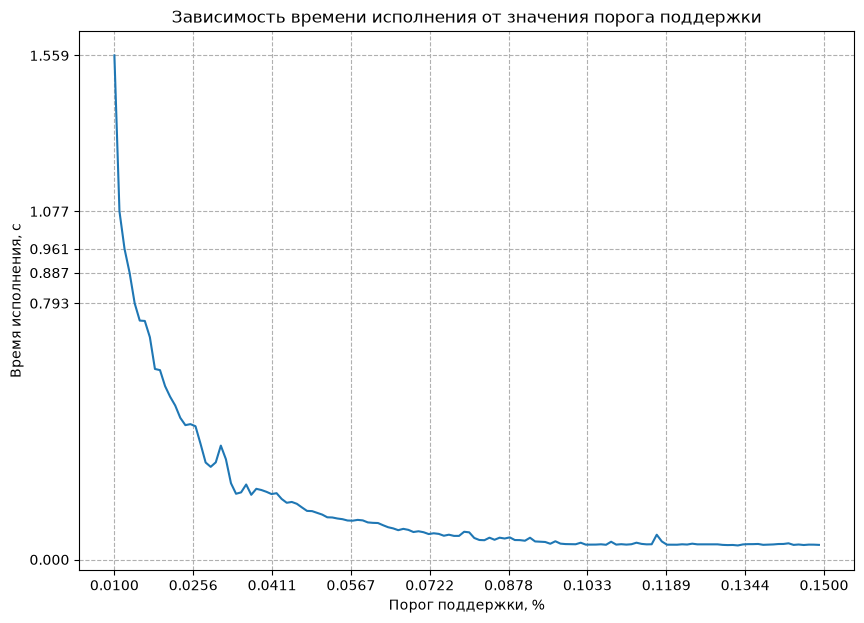

In [68]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure().set_size_inches(10, 7)
plt.title("Зависимость времени исполнения от значения порога поддержки")
plt.plot(time_values.keys(), time_values.values())
plt.xlabel("Порог поддержки, %")
plt.xticks(np.linspace(LB, UB, 10))

plt.ylabel("Время исполнения, с")
plt.yticks([0] + list(time_values.values())[:5])

plt.grid(True, ls='--')

plt.show()

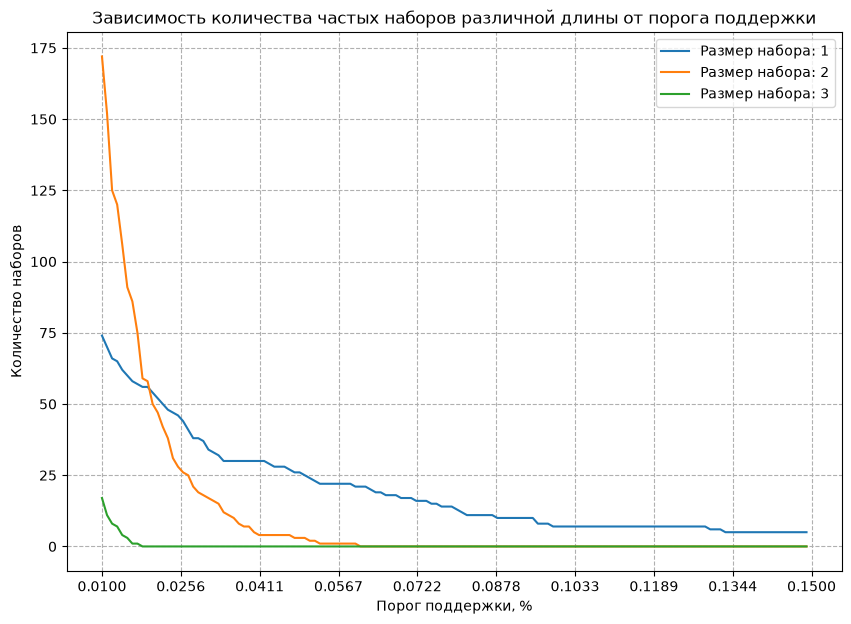

In [71]:
plt.figure().set_size_inches(10, 7)
plt.title("Зависимость количества частых наборов различной длины от порога поддержки")
plt.xlabel("Порог поддержки, %")
plt.xticks(np.linspace(LB, UB, 10))

plt.ylabel("Количество наборов")

for cardinality in list(set_counts.items())[0][1]:
    counts_by_threshold = [i.get(cardinality, 0) for i in set_counts.values()]
    plt.plot(time_values.keys(), counts_by_threshold, label=f"Размер набора: {cardinality}")

plt.grid(True, ls='--')
plt.legend()
plt.show()